# Topic: Heart Disease Prediction using Logistic Regression

## Description:
This script demonstrates the process of building, evaluating, and interpreting a Logistic Regression model for predicting heart disease. It covers data loading, exploratory data analysis (EDA), data preprocessing (including handling missing values and one-hot encoding), model training, hyperparameter tuning with regularization, and a comparison with tree-based models like Random Forest and Gradient Boosting for performance and calibration. The focus is on the interpretability of Logistic Regression coefficients and the importance of model calibration.

# 1. Introduction
This notebook focuses on predicting heart disease using a publicly available dataset (`heart.csv`) sourced from Kaggle. The primary objective is to demonstrate the application of Logistic Regression, a widely used and interpretable statistical model, for binary classification tasks in healthcare. We will cover the entire machine learning workflow, including data loading, comprehensive exploratory data analysis (EDA), robust data preprocessing techniques (handling missing values, encoding categorical features, and scaling numerical ones), and the development of a Logistic Regression model.

A key aspect of this analysis will be the interpretation of Logistic Regression coefficients, which provide insights into the impact of different features on heart disease risk. We will also explore various regularization techniques (L1, L2, ElasticNet) to optimize model performance and prevent overfitting, utilizing cross-validation for hyperparameter tuning. Finally, the performance and calibration of the Logistic Regression model will be rigorously evaluated and compared against more complex, tree-based models such as Random Forest and Gradient Boosting, highlighting the trade-offs between interpretability and predictive power.

In [156]:
# pip install kagglehub[pandas-datasets]

In [157]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from kagglehub import KaggleDatasetAdapter
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, brier_score_loss
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import roc_curve, precision_recall_curve, f1_score
import matplotlib.pyplot as plt


In [158]:


# Set the path to the file you'd like to load
file_path = "heart.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "fedesoriano/heart-failure-prediction",
  file_path,
)

SEED = 42
np.random.seed(SEED)

print("First 5 records:", df.head())

First 5 records:    Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  


In [159]:
COLORS = {'no_disease': "#21DBF3", 'disease': '#F44336', 'accent': '#FF9800', 'green': '#4CAF50'}


In [160]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [161]:
display(df.describe(include='all'))

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,918.000000,918,918,918.000000,918.000000,918.000000,918,918.000000,918,918.000000,918,918.000000
unique,NaN,2,4,NaN,NaN,NaN,3,NaN,2,NaN,3,NaN
top,NaN,M,ASY,NaN,NaN,NaN,Normal,NaN,N,NaN,Flat,NaN
freq,NaN,725,496,NaN,NaN,NaN,552,NaN,547,NaN,460,NaN
mean,53.510893,NaN,NaN,132.396514,198.799564,0.233115,NaN,136.809368,NaN,0.887364,NaN,0.553377
std,9.432617,NaN,NaN,18.514154,109.384145,0.423046,NaN,25.460334,NaN,1.066570,NaN,0.497414
min,28.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN,60.000000,NaN,-2.600000,NaN,0.000000
25%,47.000000,NaN,NaN,120.000000,173.250000,0.000000,NaN,120.000000,NaN,0.000000,NaN,0.000000
50%,54.000000,NaN,NaN,130.000000,223.000000,0.000000,NaN,138.000000,NaN,0.600000,NaN,1.000000
75%,60.000000,NaN,NaN,140.000000,267.000000,0.000000,NaN,156.000000,NaN,1.500000,NaN,1.000000


## 2. Exploratory Data Analysis (EDA)
This section performs initial data exploration to understand the distribution of variables, identify patterns, and check relationships between features and the target variable (`HeartDisease`). We visualize categorical and numerical feature distributions and examine their relationship with heart disease incidence.

In [162]:
null_values = df.isnull().sum()
features_with_nulls = null_values[null_values > 0]

if not features_with_nulls.empty:
    print("Features with null values:")
    print(features_with_nulls)
else:
    print("No features currently have null values.")


No features currently have null values.


In [163]:
# Impute missing values with the median
df['RestingBP'] = df['RestingBP'].fillna(df['RestingBP'].median())
df['Cholesterol'] = df['Cholesterol'].fillna(df['Cholesterol'].median())

# Verify that there are no more null values
print("Null values after imputation:")
print(df.isnull().sum())

Null values after imputation:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


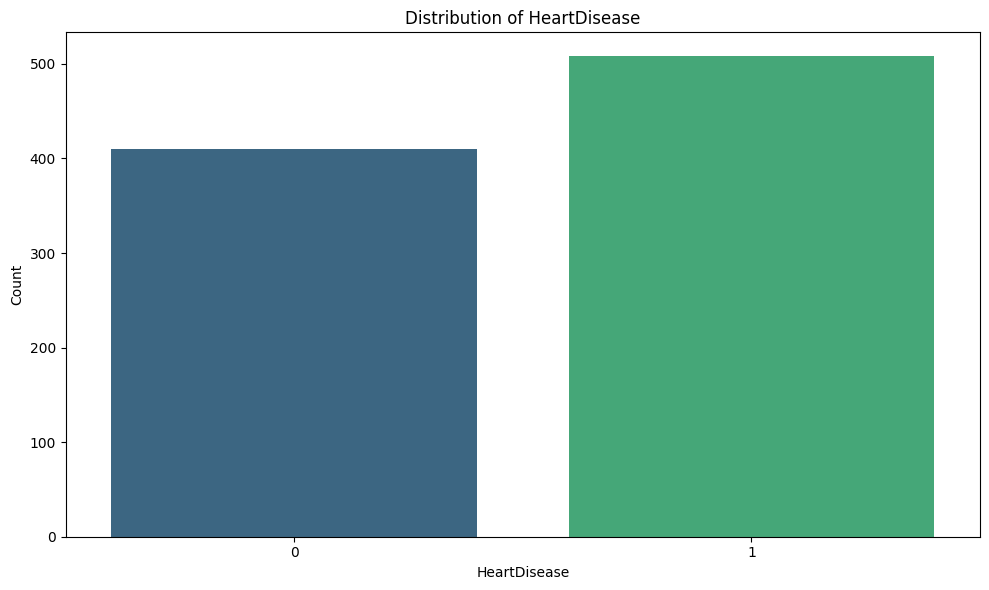

In [164]:
# HeartDisease is the target variable, so we want to see how it's distributed
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# for i, feature in enumerate('HeartDisease'):
plt.subplot(1, 1,  1) # Adjust subplot grid as needed
sns.countplot(x='HeartDisease', data=df, palette='viridis', hue='HeartDisease', legend=False)
plt.title(f'Distribution of HeartDisease')
plt.xlabel('HeartDisease')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

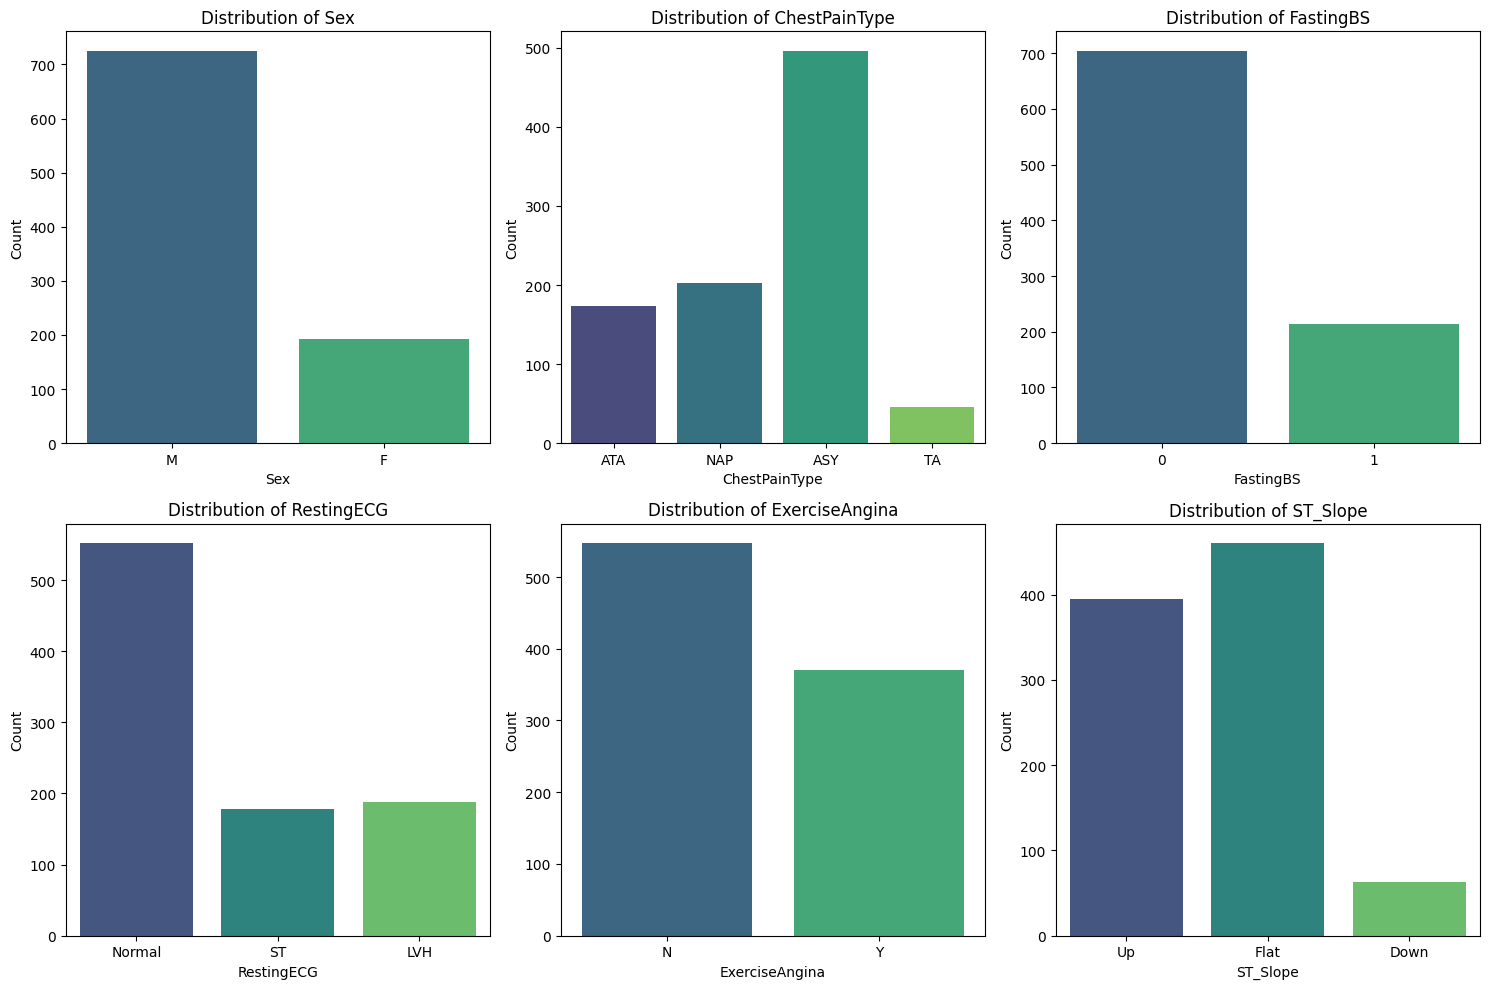

In [165]:


categorical_features =  ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(categorical_features):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid as needed
    sns.countplot(x=feature, data=df, palette='viridis', hue=feature, legend=False)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

C:\Users\Chiran\AppData\Local\Temp\ipykernel_24176\4274577492.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x=feature, data=df, kde=True, palette='viridis')
C:\Users\Chiran\AppData\Local\Temp\ipykernel_24176\4274577492.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x=feature, data=df, kde=True, palette='viridis')
C:\Users\Chiran\AppData\Local\Temp\ipykernel_24176\4274577492.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x=feature, data=df, kde=True, palette='viridis')
C:\Users\Chiran\AppData\Local\Temp\ipykernel_24176\4274577492.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x=feature, data=df, kde=True, palette='viridis')
C:\Users\Chiran\AppData\Local\Temp\ipykernel_24176\4274577492.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x=fe

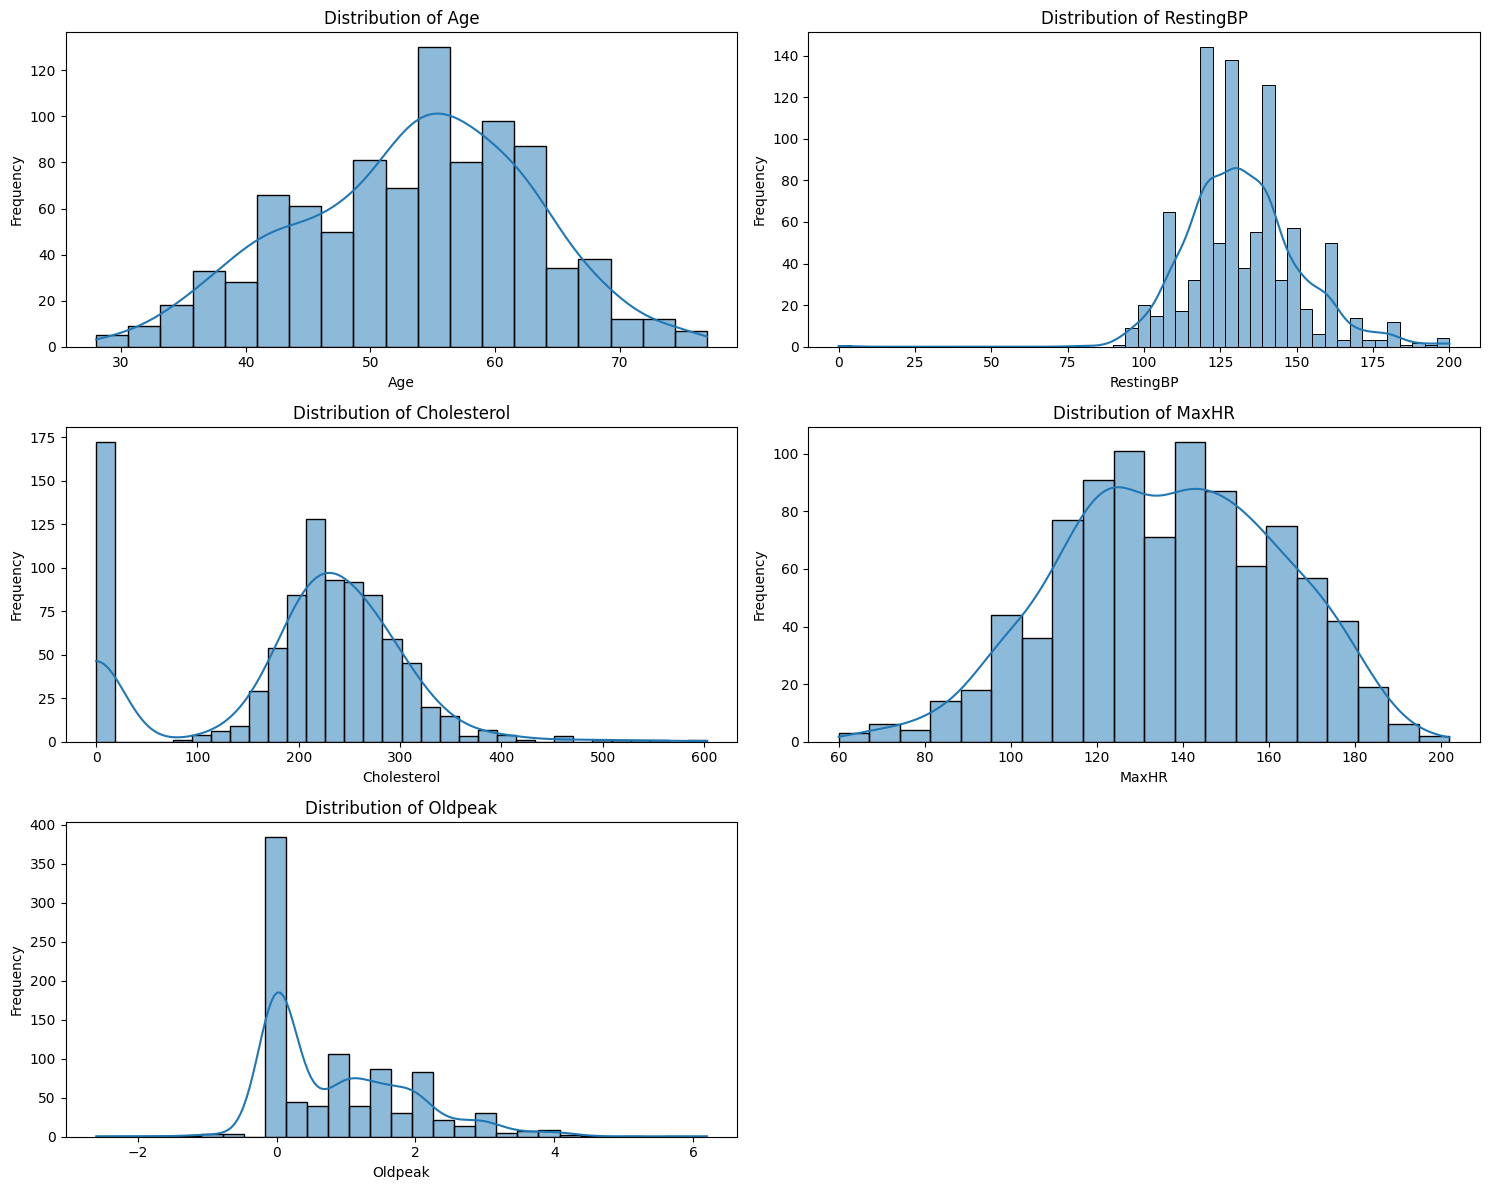

In [166]:


# Visualize continuous numerical features using histograms
continuous_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

plt.figure(figsize=(15, 12))
for i, feature in enumerate(continuous_features):
    plt.subplot(3, 2, i + 1) # Adjust subplot grid as needed
    sns.histplot(x=feature, data=df, kde=True, palette='viridis')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [167]:

# Identify non-numerical features to encode
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("DataFrame after one-hot encoding:")
display(df_encoded.head())

# Display information about the new DataFrame to confirm data types and column changes
display(df_encoded.info())

DataFrame after one-hot encoding:


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                918 non-null    int64  
 1   RestingBP          918 non-null    int64  
 2   Cholesterol        918 non-null    int64  
 3   FastingBS          918 non-null    int64  
 4   MaxHR              918 non-null    int64  
 5   Oldpeak            918 non-null    float64
 6   HeartDisease       918 non-null    int64  
 7   Sex_M              918 non-null    bool   
 8   ChestPainType_ATA  918 non-null    bool   
 9   ChestPainType_NAP  918 non-null    bool   
 10  ChestPainType_TA   918 non-null    bool   
 11  RestingECG_Normal  918 non-null    bool   
 12  RestingECG_ST      918 non-null    bool   
 13  ExerciseAngina_Y   918 non-null    bool   
 14  ST_Slope_Flat      918 non-null    bool   
 15  ST_Slope_Up        918 non-null    bool   
dtypes: bool(9), float64(1), in

None

In [168]:
# Fix zero values in Cholesterol and RestingBP — these are clearly missing, not real zeros
print(f'Cholesterol = 0: {(df["Cholesterol"] == 0).sum()} rows ({(df["Cholesterol"] == 0).mean():.1%})')
print(f'RestingBP = 0: {(df["RestingBP"] == 0).sum()} rows')

# Replace with median (grouped by HeartDisease to preserve signal)
for col in ['Cholesterol', 'RestingBP']:
    mask = df[col] == 0
    if mask.sum() > 0:
        median_by_target = df[~mask].groupby('HeartDisease')[col].median()
        for target_val in [0, 1]:
            fill_mask = mask & (df['HeartDisease'] == target_val)
            df.loc[fill_mask, col] = median_by_target[target_val]
        print(f'{col}: replaced {mask.sum()} zeros with group medians')

Cholesterol = 0: 172 rows (18.7%)
RestingBP = 0: 1 rows
Cholesterol: replaced 172 zeros with group medians
RestingBP: replaced 1 zeros with group medians


C:\Users\Chiran\AppData\Local\Temp\ipykernel_24176\3245154226.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '231.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[fill_mask, col] = median_by_target[target_val]




### Data Analysis Key Findings
*   Zero values in the 'Cholesterol' and 'RestingBP' columns were identified as potential data entry errors or missing values.
*   These zero values were imputed by replacing them with the median values of their respective columns.
*   The median imputation was performed conditionally, grouped by the 'HeartDisease' status, meaning that the median for rows with 'HeartDisease' was used for zeros in those rows, and similarly for rows without 'HeartDisease'.

### Insights or Next Steps
*   This imputation strategy helps to maintain the distribution characteristics of 'Cholesterol' and 'RestingBP' within each 'HeartDisease' group, preventing potential biases that might arise from using a global median or simply dropping the rows.
*   Further investigation could be conducted to understand the root cause of these zero values and to assess if this imputation method is the most appropriate for the dataset, potentially comparing it with other imputation techniques or domain expert consultation.


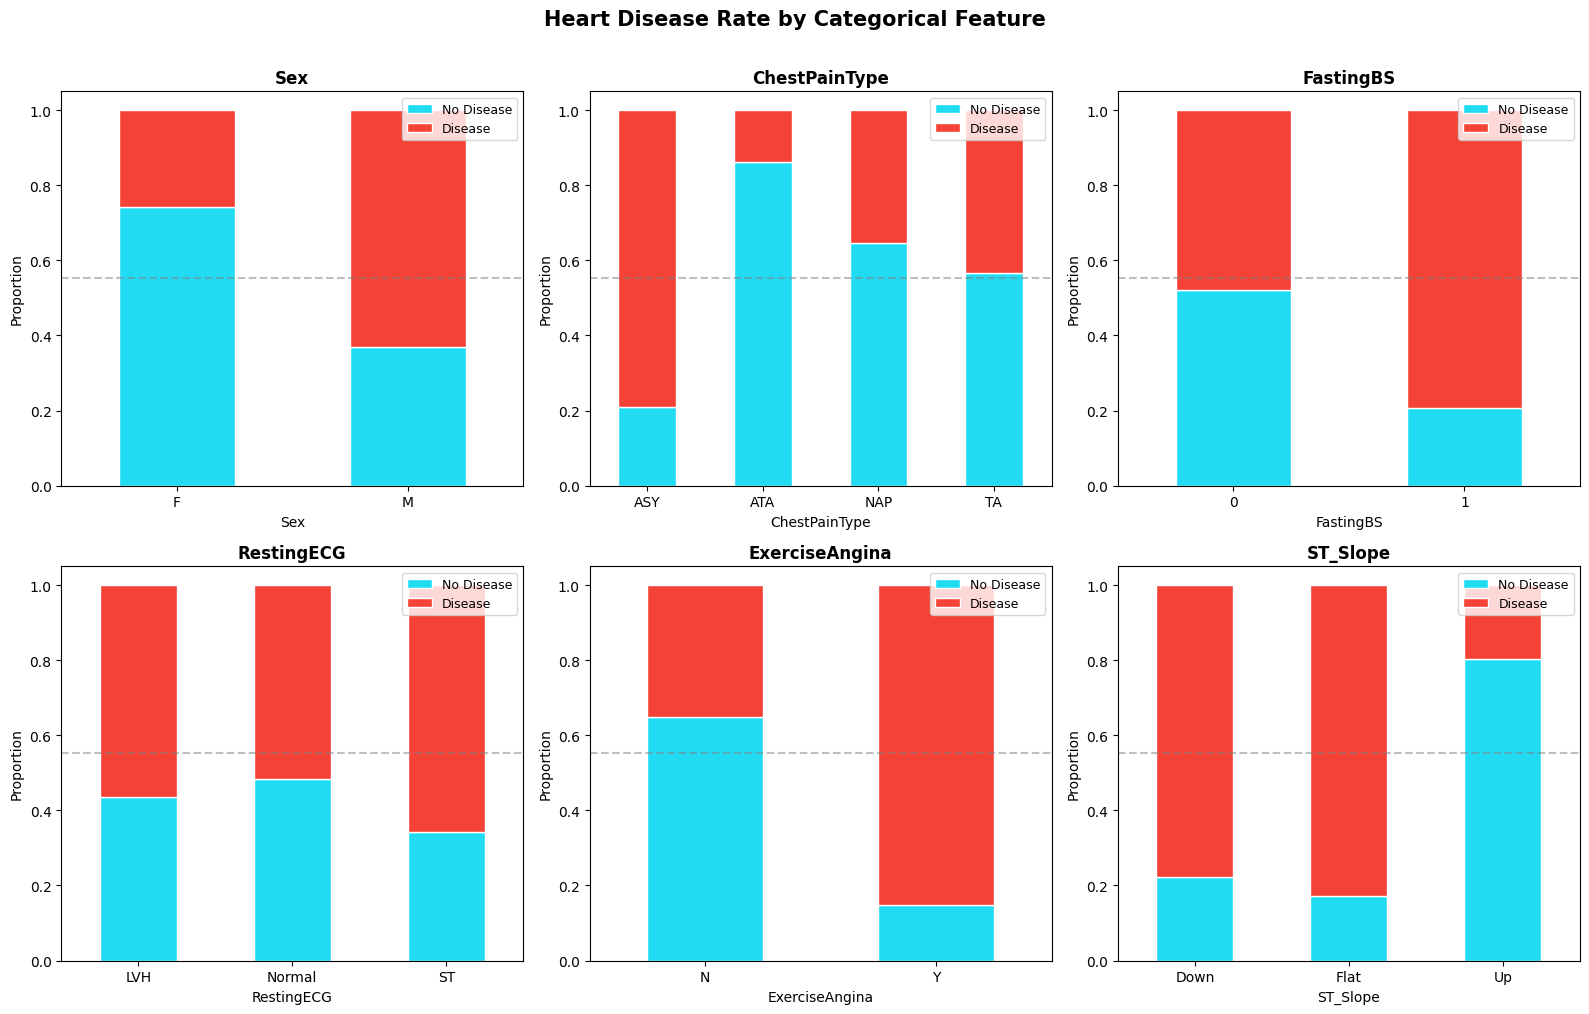

In [169]:
# Categorical features: disease rate by category
cat_cols = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, col in zip(axes.ravel(), cat_cols):
    ct = pd.crosstab(df[col], df['HeartDisease'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=ax,
            color=[COLORS['no_disease'], COLORS['disease']], edgecolor='white')
    ax.set_title(col, fontweight='bold')
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Proportion')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(['No Disease', 'Disease'], fontsize=9, loc='upper right')
    ax.axhline(df['HeartDisease'].mean(), color='gray', linestyle='--', alpha=0.5)

fig.suptitle('Heart Disease Rate by Categorical Feature', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

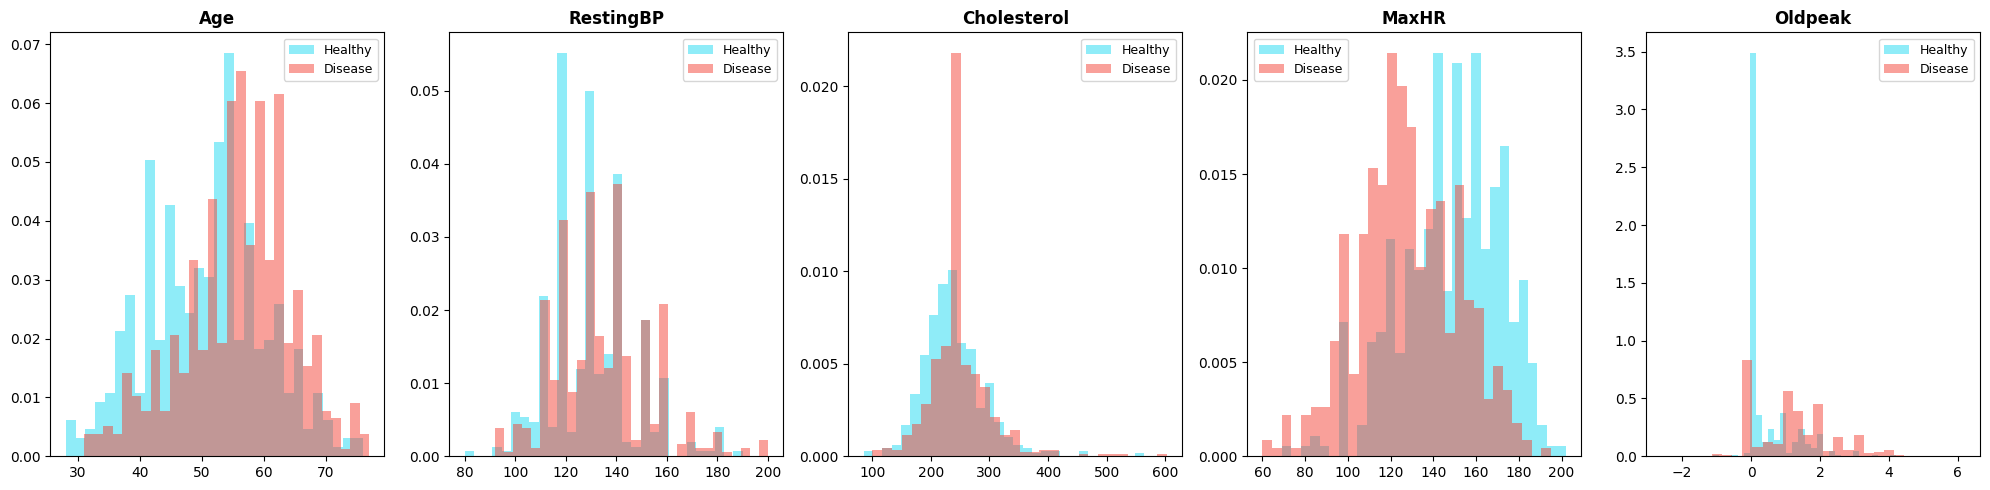

In [170]:
# Numeric features: distribution by disease status
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, col in zip(axes, num_cols):
    for label, color, name in [(0, COLORS['no_disease'], 'Healthy'), (1, COLORS['disease'], 'Disease')]:
        subset = df[df['HeartDisease'] == label][col]
        ax.hist(subset, bins=30, alpha=0.5, color=color, label=name, density=True)
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

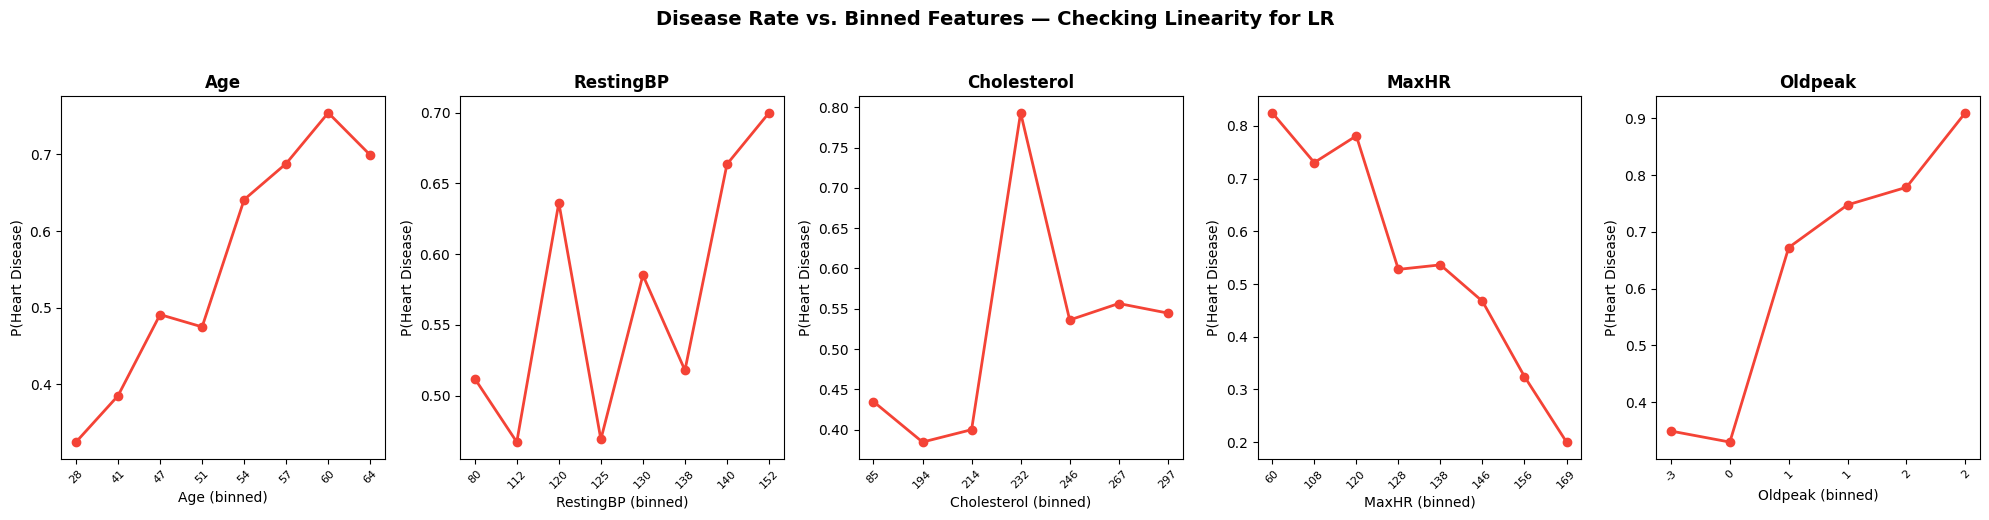

In [171]:
# Linearity check: binned means of numeric features vs. disease rate
# If the relationship is roughly monotonic, LR (with possible transforms) will work well

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, col in zip(axes, num_cols):
    # Bin the feature into quantiles
    bins = pd.qcut(df[col], q=8, duplicates='drop')
    grouped = df.groupby(bins, observed=True)['HeartDisease'].mean()

    ax.plot(range(len(grouped)), grouped.values, 'o-', color=COLORS['disease'], linewidth=2)
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('P(Heart Disease)')
    ax.set_xlabel(f'{col} (binned)')
    ax.set_xticks(range(len(grouped)))
    ax.set_xticklabels([f'{x.left:.0f}' for x in grouped.index], rotation=45, fontsize=8)

fig.suptitle('Disease Rate vs. Binned Features — Checking Linearity for LR',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

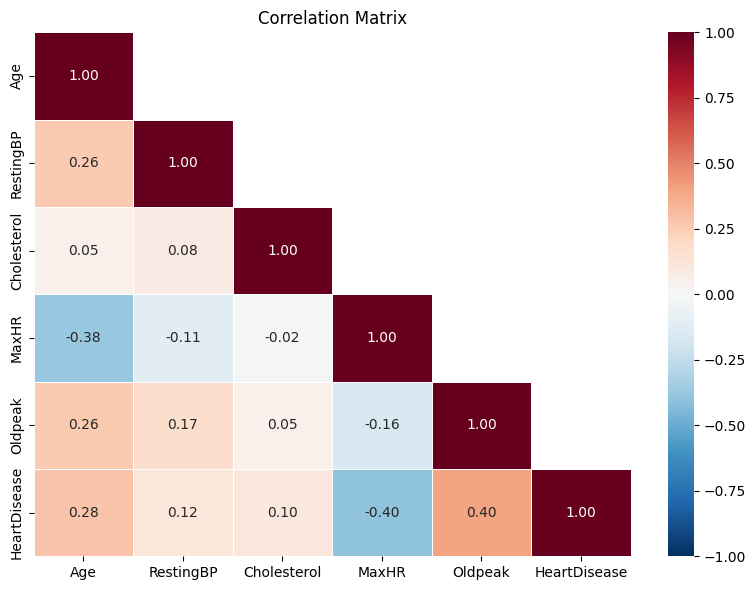

In [172]:
# Correlation matrix for numeric features
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[num_cols + ['HeartDisease']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

**EDA summary:**
- **ST_Slope** is the strongest predictor — `Flat` slope is heavily associated with disease
- **ChestPainType = ASY** (asymptomatic) is paradoxically the most dangerous — patients without obvious symptoms are more likely to have disease
- **ExerciseAngina = Y** strongly predicts disease
- **Oldpeak** (ST depression) and **MaxHR** are the strongest numeric predictors
- **Cholesterol** is surprisingly weak after fixing the zeros — this is known in the literature
- No extreme multicollinearity between numeric features

---

## 4. Data Preprocessing
This section prepares the data for model training. It involves splitting the data into training and testing sets, handling categorical variables through one-hot encoding, and scaling numerical features to ensure all features contribute equally to the model.

In [173]:
from sklearn.model_selection import train_test_split

# Define feature types
numeric_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

# FastingBS is already binary (0/1), treat as numeric
binary_features = ['FastingBS']

# Nominal categoricals — no natural order → one-hot encoding
nominal_features = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina']

# ST_Slope has a clinical order: Down < Flat < Up (in terms of being normal)
ordinal_features = ['ST_Slope']

X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

# Train/test split — stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'Train: {X_train.shape[0]} samples ({y_train.mean():.1%} disease)')
print(f'Test:  {X_test.shape[0]} samples ({y_test.mean():.1%} disease)')

Train: 734 samples (55.3% disease)
Test:  184 samples (55.4% disease)


In [174]:

# Build preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('bin', 'passthrough', binary_features),
        ('nom', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), nominal_features),
        ('ord', OrdinalEncoder(categories=[['Down', 'Flat', 'Up']]), ordinal_features),
    ],
    remainder='drop'
)

# Fit on training data and check the output
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get feature names after transformation
num_names = numeric_features
bin_names = binary_features
nom_names = preprocessor.named_transformers_['nom'].get_feature_names_out(nominal_features).tolist()
ord_names = ['ST_Slope_ordinal']
all_feature_names = num_names + bin_names + nom_names + ord_names

print(f'Features after encoding: {len(all_feature_names)}')
print(f'Names: {all_feature_names}')

Features after encoding: 14
Names: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'FastingBS', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_ordinal']


## 5. Model Development (Logistic Regression)
Here, we build and train our primary model: Logistic Regression. We start with a baseline model, interpret its coefficients, and then explore different regularization techniques (L1, L2, ElasticNet) to prevent overfitting and improve generalization. Cross-validation is used to find optimal hyperparameters.

In [175]:

lr_baseline = LogisticRegression(random_state=SEED, max_iter=1000)
lr_baseline.fit(X_train_processed, y_train)

y_pred = lr_baseline.predict(X_test_processed)
y_prob = lr_baseline.predict_proba(X_test_processed)[:, 1]

print('=== Baseline Logistic Regression ===')
print(f'\n{classification_report(y_test, y_pred, target_names=["Healthy", "Disease"])}')
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')
print(f'Average Precision: {average_precision_score(y_test, y_prob):.4f}')
print(f'Brier Score: {brier_score_loss(y_test, y_prob):.4f} (lower is better)')

=== Baseline Logistic Regression ===

              precision    recall  f1-score   support

     Healthy       0.88      0.82      0.85        82
     Disease       0.86      0.91      0.89       102

    accuracy                           0.87       184
   macro avg       0.87      0.86      0.87       184
weighted avg       0.87      0.87      0.87       184

ROC-AUC: 0.9071
Average Precision: 0.9003
Brier Score: 0.1111 (lower is better)


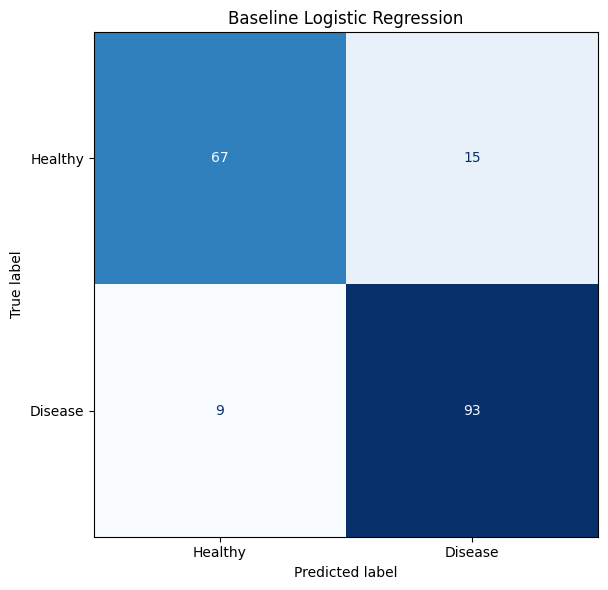

In [176]:

# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['Healthy', 'Disease'],
    cmap='Blues', ax=ax, colorbar=False
)
ax.set_title('Baseline Logistic Regression')
plt.tight_layout()
plt.show()

In [177]:
# Extract and display coefficients
coef_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': lr_baseline.coef_[0],
    'Odds_Ratio': np.exp(lr_baseline.coef_[0])
}).sort_values('Coefficient')

print('Intercept:', f'{lr_baseline.intercept_[0]:.4f}')
print(f'\nCoefficients and Odds Ratios:')
print(coef_df.to_string(index=False, float_format='%.4f'))

Intercept: 1.9763

Coefficients and Odds Ratios:
          Feature  Coefficient  Odds_Ratio
 ST_Slope_ordinal      -1.7559      0.1728
ChestPainType_ATA      -1.6039      0.2011
ChestPainType_NAP      -1.4606      0.2321
 ChestPainType_TA      -1.0805      0.3394
            MaxHR      -0.3569      0.6999
RestingECG_Normal      -0.1576      0.8542
    RestingECG_ST      -0.1299      0.8782
        RestingBP       0.0028      1.0028
              Age       0.0424      1.0433
      Cholesterol       0.1351      1.1447
          Oldpeak       0.1882      1.2071
 ExerciseAngina_Y       0.9546      2.5975
        FastingBS       1.0924      2.9815
            Sex_M       1.2156      3.3723


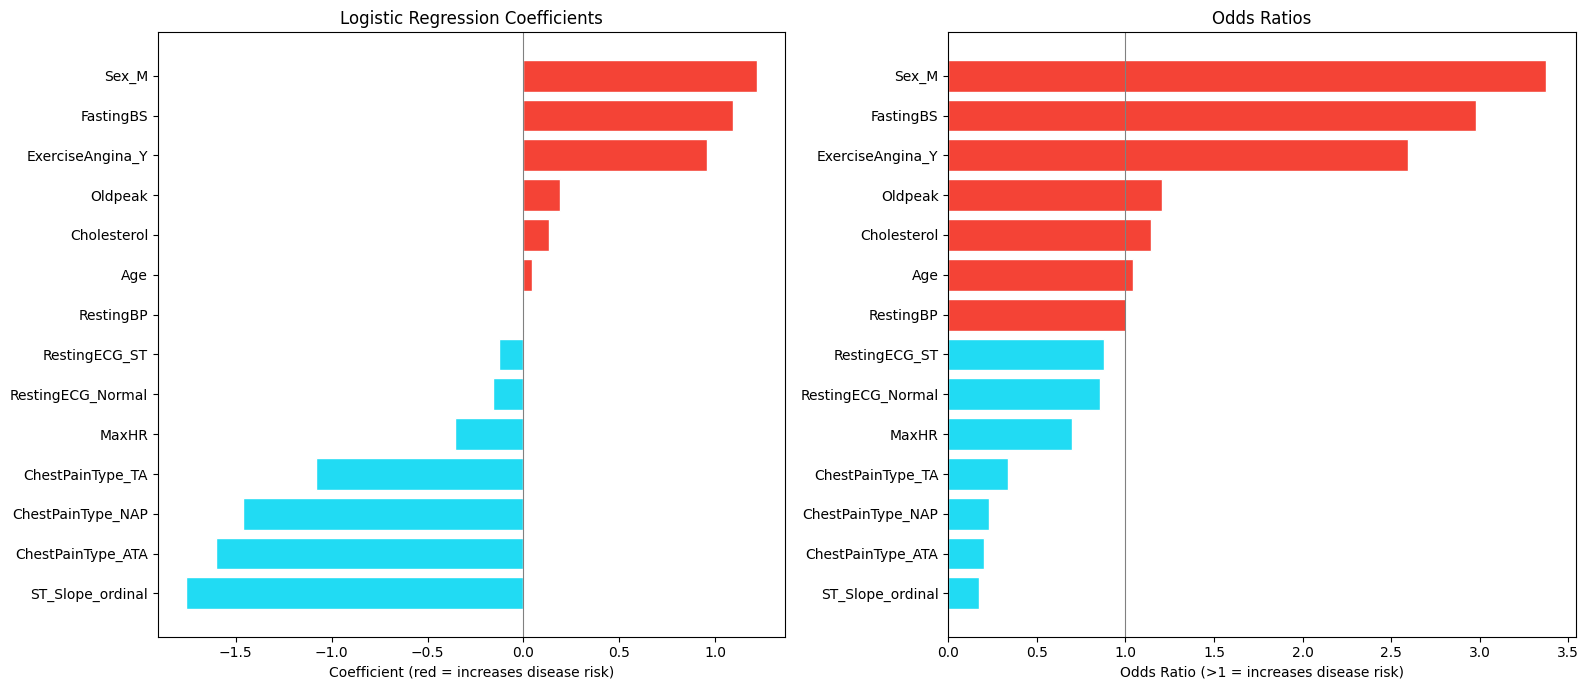

In [178]:
# Coefficient plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Coefficients
colors = [COLORS['disease'] if c > 0 else COLORS['no_disease'] for c in coef_df['Coefficient']]
axes[0].barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
axes[0].axvline(0, color='gray', linewidth=0.8)
axes[0].set_title('Logistic Regression Coefficients')
axes[0].set_xlabel('Coefficient (red = increases disease risk)')

# Odds ratios
or_sorted = coef_df.sort_values('Odds_Ratio')
colors_or = [COLORS['disease'] if o > 1 else COLORS['no_disease'] for o in or_sorted['Odds_Ratio']]
axes[1].barh(or_sorted['Feature'], or_sorted['Odds_Ratio'], color=colors_or, edgecolor='white')
axes[1].axvline(1, color='gray', linewidth=0.8)
axes[1].set_title('Odds Ratios')
axes[1].set_xlabel('Odds Ratio (>1 = increases disease risk)')

plt.tight_layout()
plt.show()

In [179]:
# Plain English interpretation of the top features
print('=== Coefficient Interpretation (features are standardized) ===')
print()

top_risk = coef_df.nlargest(5, 'Coefficient')
top_protective = coef_df.nsmallest(5, 'Coefficient')

print('TOP 5 RISK FACTORS (increase disease probability):')
for _, row in top_risk.iterrows():
    direction = 'increases' if row['Odds_Ratio'] > 1 else 'decreases'
    factor = row['Odds_Ratio'] if row['Odds_Ratio'] > 1 else 1/row['Odds_Ratio']
    print(f"  {row['Feature']:30s} OR={row['Odds_Ratio']:.2f}  "
          f"→ {direction} odds by {(factor-1)*100:.0f}%")

print(f'\nTOP 5 PROTECTIVE FACTORS (decrease disease probability):')
for _, row in top_protective.iterrows():
    direction = 'increases' if row['Odds_Ratio'] > 1 else 'decreases'
    factor = row['Odds_Ratio'] if row['Odds_Ratio'] > 1 else 1/row['Odds_Ratio']
    print(f"  {row['Feature']:30s} OR={row['Odds_Ratio']:.2f}  "
          f"→ {direction} odds by {(factor-1)*100:.0f}%")

=== Coefficient Interpretation (features are standardized) ===

TOP 5 RISK FACTORS (increase disease probability):
  Sex_M                          OR=3.37  → increases odds by 237%
  FastingBS                      OR=2.98  → increases odds by 198%
  ExerciseAngina_Y               OR=2.60  → increases odds by 160%
  Oldpeak                        OR=1.21  → increases odds by 21%
  Cholesterol                    OR=1.14  → increases odds by 14%

TOP 5 PROTECTIVE FACTORS (decrease disease probability):
  ST_Slope_ordinal               OR=0.17  → decreases odds by 479%
  ChestPainType_ATA              OR=0.20  → decreases odds by 397%
  ChestPainType_NAP              OR=0.23  → decreases odds by 331%
  ChestPainType_TA               OR=0.34  → decreases odds by 195%
  MaxHR                          OR=0.70  → decreases odds by 43%


In [180]:

# Compare regularization types with CV
results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

configs = [
    ('L2 (Ridge)', 'l2', 'lbfgs'),
    ('L1 (Lasso)', 'l1', 'liblinear'),
    ('ElasticNet', 'elasticnet', 'saga'),
('No regularization', None, 'lbfgs'),
]

for name, penalty, solver in configs:
    kwargs = {'penalty': penalty, 'solver': solver, 'random_state': SEED, 'max_iter': 5000}
    if penalty == 'elasticnet':
        kwargs['l1_ratio'] = 0.5

    model = LogisticRegression(**kwargs)
    scores = cross_val_score(model, X_train_processed, y_train, cv=cv, scoring='roc_auc')
    results.append({
        'Penalty': name,
        'Mean AUC': scores.mean(),
        'Std': scores.std(),
    })

reg_df = pd.DataFrame(results)
print(reg_df.to_string(index=False, float_format='%.4f'))

          Penalty  Mean AUC    Std
       L2 (Ridge)    0.9155 0.0354
       L1 (Lasso)    0.9159 0.0346
       ElasticNet    0.9157 0.0353
No regularization    0.9142 0.0370


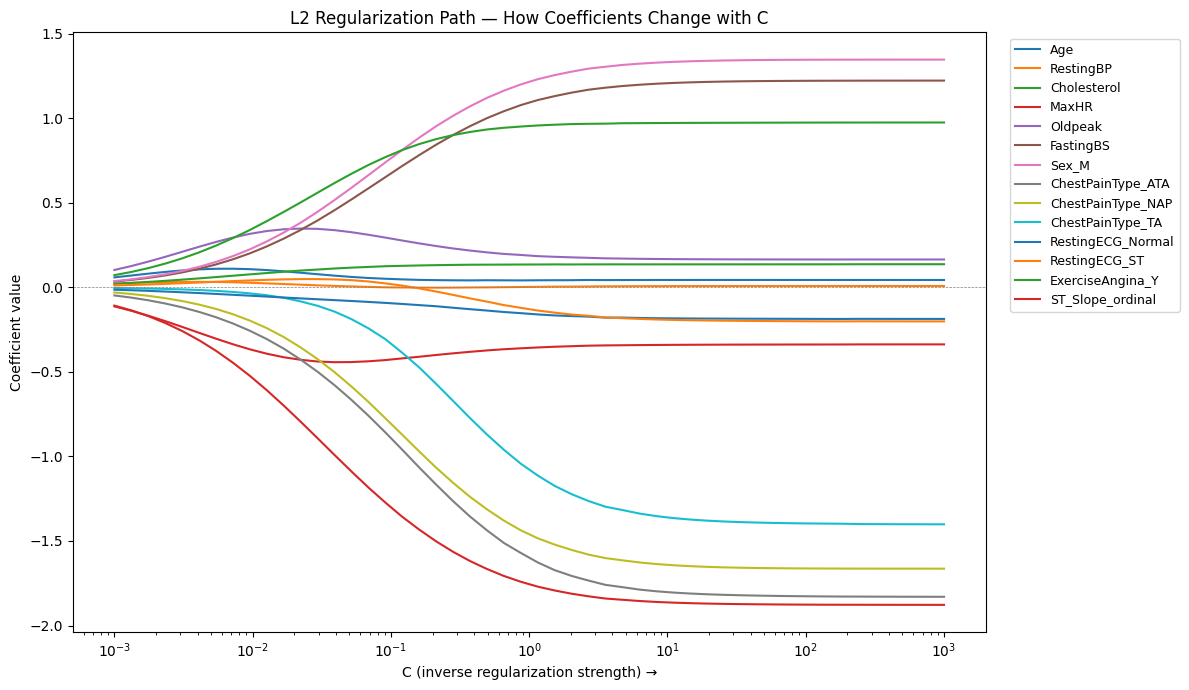

Left side (small C): strong regularization, all coefficients squeezed toward zero.
Right side (large C): weak regularization, coefficients reach their unrestricted values.
The stable features on the right are the ones the model is most confident about.


In [181]:
# Regularization path — how coefficients change with C
C_values = np.logspace(-3, 3, 50)
coef_paths = {feat: [] for feat in all_feature_names}

for C in C_values:
    model = LogisticRegression(C=C, penalty='l2', random_state=SEED, max_iter=5000)
    model.fit(X_train_processed, y_train)
    for i, feat in enumerate(all_feature_names):
        coef_paths[feat].append(model.coef_[0][i])

fig, ax = plt.subplots(figsize=(12, 7))
for feat in all_feature_names:
    ax.plot(C_values, coef_paths[feat], linewidth=1.5, label=feat)

ax.set_xscale('log')
ax.set_xlabel('C (inverse regularization strength) →')
ax.set_ylabel('Coefficient value')
ax.set_title('L2 Regularization Path — How Coefficients Change with C')
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

print('Left side (small C): strong regularization, all coefficients squeezed toward zero.')
print('Right side (large C): weak regularization, coefficients reach their unrestricted values.')
print('The stable features on the right are the ones the model is most confident about.')

In [182]:
# L1 feature selection — which features survive?
lr_l1 = LogisticRegression(penalty='l1', solver='liblinear', C=0.5, random_state=SEED, max_iter=5000)
lr_l1.fit(X_train_processed, y_train)

l1_coefs = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': lr_l1.coef_[0],
    'Kept': lr_l1.coef_[0] != 0
})

print(f'L1 with C=0.5 keeps {l1_coefs["Kept"].sum()} / {len(l1_coefs)} features:')
kept = l1_coefs[l1_coefs['Kept']].sort_values('Coefficient', key=abs, ascending=False)
print(kept[['Feature', 'Coefficient']].to_string(index=False, float_format='%.4f'))

dropped = l1_coefs[~l1_coefs['Kept']]['Feature'].tolist()
if dropped:
    print(f'\nDropped by L1: {dropped}')

L1 with C=0.5 keeps 11 / 14 features:
          Feature  Coefficient
 ST_Slope_ordinal      -1.6191
ChestPainType_ATA      -1.5184
ChestPainType_NAP      -1.3245
            Sex_M       1.2393
        FastingBS       1.0235
 ExerciseAngina_Y       0.9953
 ChestPainType_TA      -0.7980
            MaxHR      -0.3423
          Oldpeak       0.1867
      Cholesterol       0.1321
              Age       0.0455

Dropped by L1: ['RestingBP', 'RestingECG_Normal', 'RestingECG_ST']


Best C: 0.6158


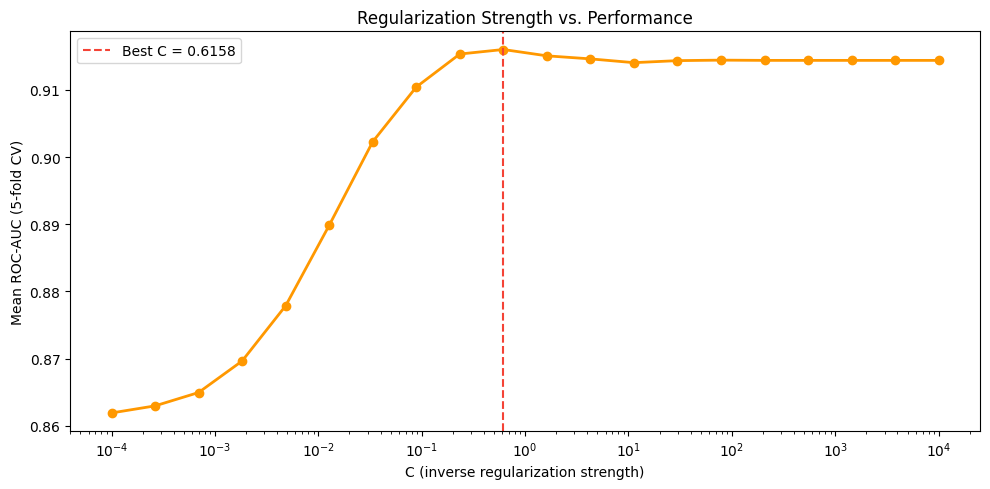


=== Optimized LR (C=0.6158) ===

              precision    recall  f1-score   support

     Healthy       0.88      0.82      0.85        82
     Disease       0.86      0.91      0.89       102

    accuracy                           0.87       184
   macro avg       0.87      0.86      0.87       184
weighted avg       0.87      0.87      0.87       184

ROC-AUC: 0.9081


In [183]:
# Find optimal C using built-in CV
lr_cv = LogisticRegressionCV(
    Cs=20,  # try 20 values of C
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
    scoring='roc_auc',
    penalty='l2',
    random_state=SEED,
    max_iter=5000,
    n_jobs=-1
)
lr_cv.fit(X_train_processed, y_train)

print(f'Best C: {lr_cv.C_[0]:.4f}')

# Plot AUC vs C
mean_scores = lr_cv.scores_[1].mean(axis=0)  # class 1 scores
cs = lr_cv.Cs_

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cs, mean_scores, 'o-', color=COLORS['accent'], linewidth=2)
ax.axvline(lr_cv.C_[0], color=COLORS['disease'], linestyle='--', label=f'Best C = {lr_cv.C_[0]:.4f}')
ax.set_xscale('log')
ax.set_xlabel('C (inverse regularization strength)')
ax.set_ylabel('Mean ROC-AUC (5-fold CV)')
ax.set_title('Regularization Strength vs. Performance')
ax.legend()
plt.tight_layout()
plt.show()

# Evaluate on test set
y_pred_cv = lr_cv.predict(X_test_processed)
y_prob_cv = lr_cv.predict_proba(X_test_processed)[:, 1]

print(f'\n=== Optimized LR (C={lr_cv.C_[0]:.4f}) ===')
print(f'\n{classification_report(y_test, y_pred_cv, target_names=["Healthy", "Disease"])}')
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_cv):.4f}')

# Calibration



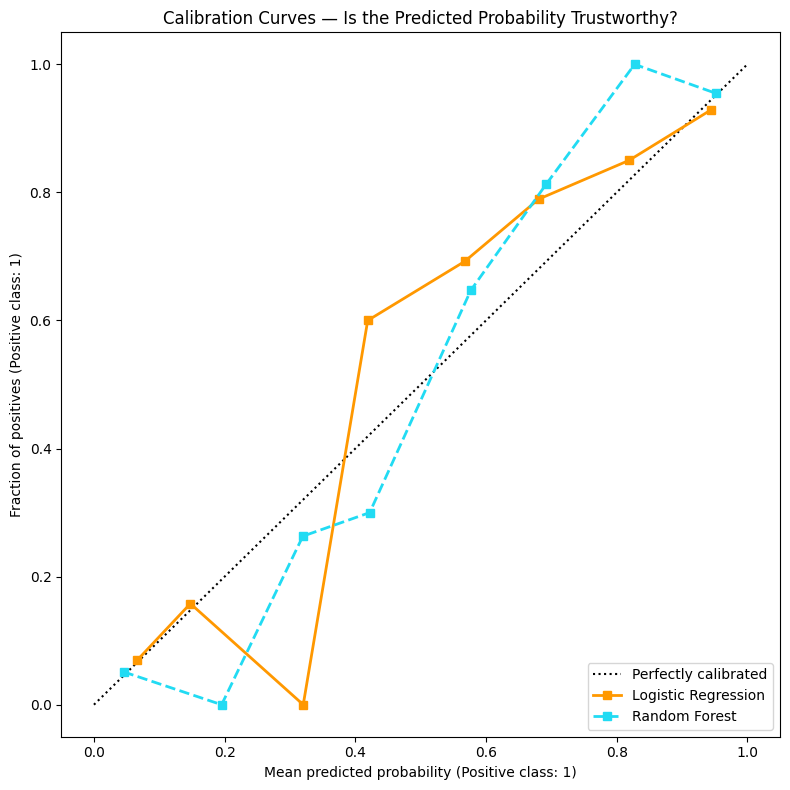

Brier Scores (lower = better calibration):
  Logistic Regression: 0.1111
  Random Forest:       0.0939
  Gradient Boosting:   0.0847

Closer to the diagonal = better calibrated. LR is typically the most calibrated.


In [184]:


# Train tree-based models for comparison
rf = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
rf.fit(X_train_processed, y_train)
y_prob_rf = rf.predict_proba(X_test_processed)[:, 1]

# gb = GradientBoostingClassifier(n_estimators=200, random_state=SEED)
# gb.fit(X_train_processed, y_train)
# y_prob_gb = gb.predict_proba(X_test_processed)[:, 1]

# Calibration plot
fig, ax = plt.subplots(figsize=(8, 8))

CalibrationDisplay.from_predictions(
    y_test, y_prob_cv, n_bins=8, name='Logistic Regression', ax=ax,
    color=COLORS['accent'], linewidth=2
)
CalibrationDisplay.from_predictions(
    y_test, y_prob_rf, n_bins=8, name='Random Forest', ax=ax,
    color=COLORS['no_disease'], linewidth=2, linestyle='--'
)
# CalibrationDisplay.from_predictions(
#     y_test, y_prob_gb, n_bins=8, name='Gradient Boosting', ax=ax,
#     color=COLORS['disease'], linewidth=2, linestyle='--'
# )

ax.set_title('Calibration Curves — Is the Predicted Probability Trustworthy?')
plt.tight_layout()
plt.show()

print('Brier Scores (lower = better calibration):')
print(f'  Logistic Regression: {brier_score_loss(y_test, y_prob_cv):.4f}')
print(f'  Random Forest:       {brier_score_loss(y_test, y_prob_rf):.4f}')
print(f'  Gradient Boosting:   {brier_score_loss(y_test, y_prob_gb):.4f}')
print('\nCloser to the diagonal = better calibrated. LR is typically the most calibrated.')

## 6. Model Evaluation and Comparison
This section evaluates the performance of the optimized Logistic Regression model and compares it against tree-based models like Random Forest and Gradient Boosting. We assess classification metrics such as ROC-AUC, Precision-Recall curves, F1-score, and importantly, model calibration using Brier Scores and Calibration Curves.

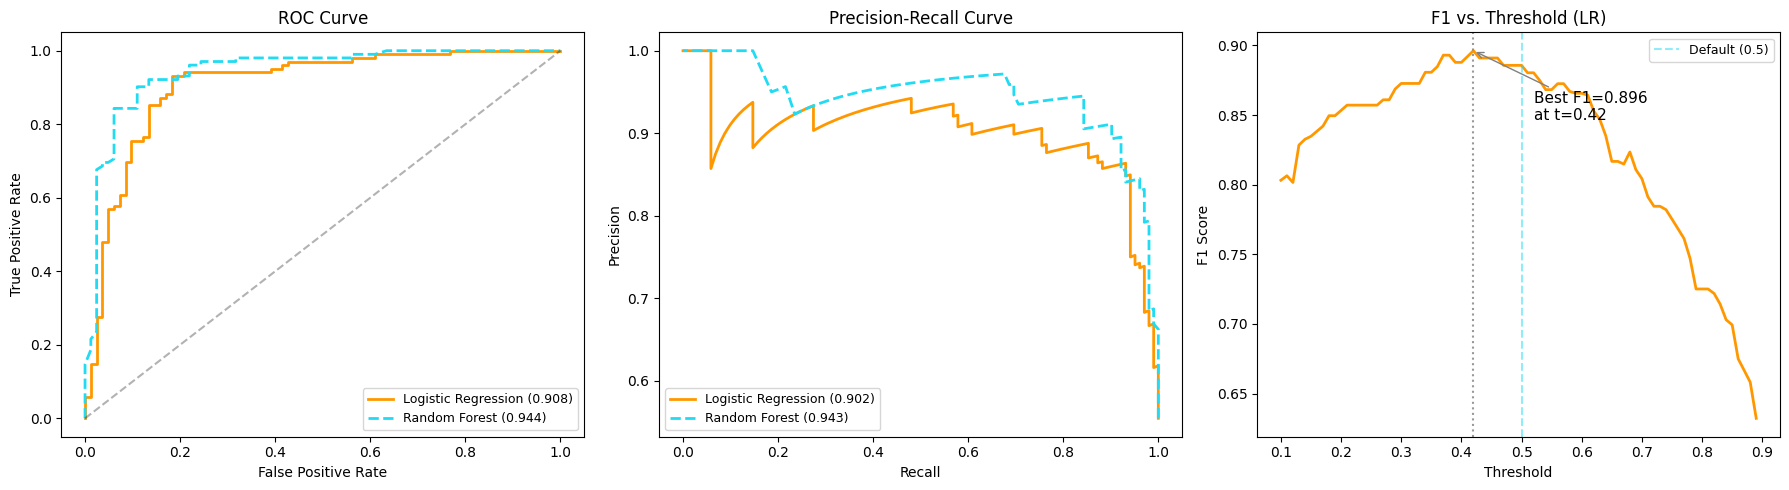

In [185]:


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC curve comparison
for y_p, name, color, ls in [(y_prob_cv, 'Logistic Regression', COLORS['accent'], '-'),
                               (y_prob_rf, 'Random Forest', COLORS['no_disease'], '--'),
                            #    (y_prob_gb, 'Gradient Boosting', COLORS['disease'], '--')
                               ]:
    fpr, tpr, _ = roc_curve(y_test, y_p)
    auc = roc_auc_score(y_test, y_p)
    axes[0].plot(fpr, tpr, label=f'{name} ({auc:.3f})', color=color, linewidth=2, linestyle=ls)
axes[0].plot([0,1], [0,1], 'k--', alpha=0.3)
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9)

# PR curve comparison
for y_p, name, color, ls in [(y_prob_cv, 'Logistic Regression', COLORS['accent'], '-'),
                               (y_prob_rf, 'Random Forest', COLORS['no_disease'], '--'),
                            #    (y_prob_gb, 'Gradient Boosting', COLORS['disease'], '--')
                               ]:
    prec, rec, _ = precision_recall_curve(y_test, y_p)
    ap = average_precision_score(y_test, y_p)
    axes[1].plot(rec, prec, label=f'{name} ({ap:.3f})', color=color, linewidth=2, linestyle=ls)
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=9)

# Threshold selection for LR
thresholds = np.arange(0.1, 0.9, 0.01)
f1s = [f1_score(y_test, (y_prob_cv >= t).astype(int)) for t in thresholds]
best_t = thresholds[np.argmax(f1s)]

axes[2].plot(thresholds, f1s, color=COLORS['accent'], linewidth=2)
axes[2].axvline(best_t, color='gray', linestyle=':', alpha=0.8)
axes[2].axvline(0.5, color=COLORS['no_disease'], linestyle='--', alpha=0.5, label='Default (0.5)')
axes[2].annotate(f'Best F1={max(f1s):.3f}\nat t={best_t:.2f}',
                xy=(best_t, max(f1s)), xytext=(best_t + 0.1, max(f1s) - 0.05),
                arrowprops=dict(arrowstyle='->', color='gray'), fontsize=11)
axes[2].set_title('F1 vs. Threshold (LR)')
axes[2].set_xlabel('Threshold')
axes[2].set_ylabel('F1 Score')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

In [186]:
# Head-to-head comparison
models_compare = {
    'Logistic Regression': y_prob_cv,
    'Random Forest': y_prob_rf,
    # 'Gradient Boosting': y_prob_gb,
}

comparison = []
for name, y_p in models_compare.items():
    y_pred_comp = (y_p >= 0.5).astype(int)
    comparison.append({
        'Model': name,
        'Accuracy': (y_pred_comp == y_test).mean(),
        'F1': f1_score(y_test, y_pred_comp),
        'ROC-AUC': roc_auc_score(y_test, y_p),
        'PR-AUC': average_precision_score(y_test, y_p),
        'Brier': brier_score_loss(y_test, y_p),
    })

comp_df = pd.DataFrame(comparison)
print(comp_df.to_string(index=False, float_format='%.4f'))
print('\nLogistic Regression is competitive with tree-based models on this dataset.')
print('And it gives you interpretable coefficients and calibrated probabilities for free.')

              Model  Accuracy     F1  ROC-AUC  PR-AUC  Brier
Logistic Regression    0.8696 0.8857   0.9081  0.9016 0.1111
      Random Forest    0.8859 0.8976   0.9442  0.9430 0.0939

Logistic Regression is competitive with tree-based models on this dataset.
And it gives you interpretable coefficients and calibrated probabilities for free.
